--- RESULTADOS DE LOS DIFERENTES KERNELS ---

=== KERNEL: LINEAR ===
              precision    recall  f1-score   support

           0       0.80      0.94      0.87      2287
           1       0.58      0.27      0.36       713

    accuracy                           0.78      3000
   macro avg       0.69      0.60      0.62      3000
weighted avg       0.75      0.78      0.75      3000



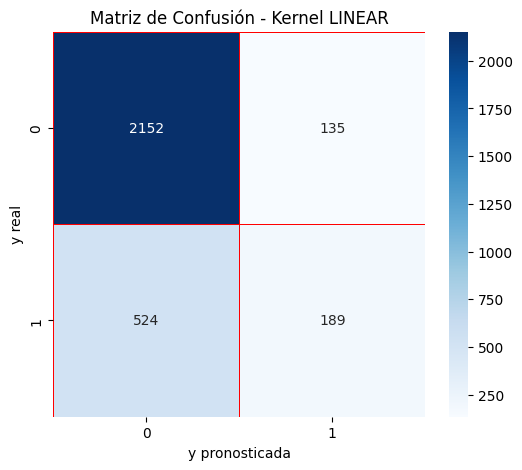

=== KERNEL: POLY ===
              precision    recall  f1-score   support

           0       0.95      0.98      0.96      2287
           1       0.92      0.84      0.88       713

    accuracy                           0.94      3000
   macro avg       0.93      0.91      0.92      3000
weighted avg       0.94      0.94      0.94      3000



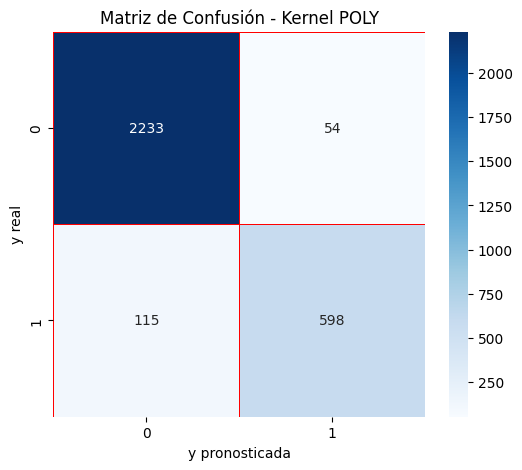

=== KERNEL: RBF ===
              precision    recall  f1-score   support

           0       0.97      0.98      0.97      2287
           1       0.92      0.90      0.91       713

    accuracy                           0.96      3000
   macro avg       0.94      0.94      0.94      3000
weighted avg       0.96      0.96      0.96      3000



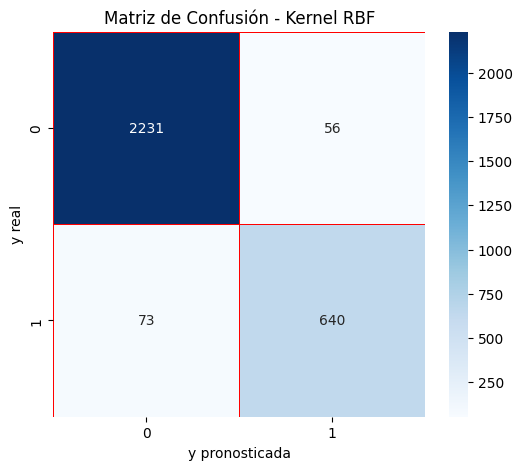

=== KERNEL: SIGMOID ===
              precision    recall  f1-score   support

           0       0.76      0.77      0.76      2287
           1       0.22      0.20      0.21       713

    accuracy                           0.64      3000
   macro avg       0.49      0.49      0.49      3000
weighted avg       0.63      0.64      0.63      3000



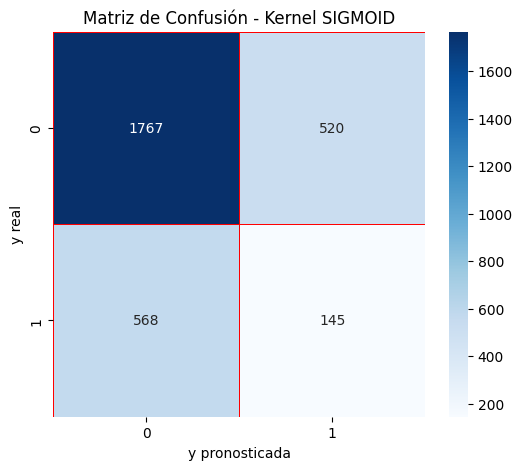


--- PRONÓSTICO PARA EL EMPLEADO DE LA RÚBRICA ---
Resultado predictivo: SE QUEDARÁ en la empresa (0)


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn import svm
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# 1. Configurar la ruta de trabajo
os.chdir(r"C:\Users\Yamil\OneDrive\Escritorio\Escritorio\Yamil\EBAC (CIENCIA DE DATOS)\Bloque 4 Aprendizaje de máquina supervisado\MOD 4 Mac Soporte Vectorial")

# 2. Cargar la base de datos
df = pd.read_csv("recursos_humanos.csv")

# 3. Preprocesamiento: Re-codificar variables categóricas
# Usamos pd.get_dummies para las columnas 'sales' y 'salary'
df_encoded = pd.get_dummies(df, columns=['sales', 'salary'], drop_first=True)

# 4. Separación de datos
X = df_encoded.drop('left', axis=1)
y = df_encoded['left']

# Dividimos en 80% entrenamiento y 20% prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=4)

# 5. Escalado de Datos (Crucial para Máquinas de Soporte Vectorial)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 6. Modelación con los 4 tipos de Kernel
kernels = ['linear', 'poly', 'rbf', 'sigmoid']

print("--- RESULTADOS DE LOS DIFERENTES KERNELS ---\n")

for k in kernels:
    print(f"=== KERNEL: {k.upper()} ===")
    
    # Entrenar el modelo
    clf = svm.SVC(kernel=k, random_state=4)
    clf.fit(X_train_scaled, y_train)
    
    # Predecir
    y_pred = clf.predict(X_test_scaled)
    
    # Reporte de clasificación
    print(classification_report(y_test, y_pred))
    
    # Matriz de Confusión
    cm = confusion_matrix(y_test, y_pred)
    
    # Visualización (Mapa de calor)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, linewidth=0.5, linecolor="red", fmt="d", cmap="Blues")
    plt.xlabel("y pronosticada")
    plt.ylabel("y real")
    plt.title(f"Matriz de Confusión - Kernel {k.upper()}")
    
    # Guardar gráfica en alta calidad para el reporte
    nombre_archivo = f"matriz_confusion_{k}.png"
    plt.savefig(nombre_archivo, facecolor='white', dpi=300, bbox_inches='tight')
    plt.show()

# 7. PRONÓSTICO DEL NUEVO EMPLEADO (Tabla 2)
# Datos exactos de la rúbrica
nuevo_empleado = pd.DataFrame({
    'satisfaction_level': [0.5],
    'last_evaluation': [0.75],
    'number_project': [4],
    'average_montly_hours': [200],
    'time_spend_company': [4],
    'Work_accident': [0],
    'promotion_last_5years': [0],
    'sales': ['sales'],
    'salary': ['medium']
})

# Mismo tratamiento que a nuestros datos base
nuevo_empleado_encoded = pd.get_dummies(nuevo_empleado, columns=['sales', 'salary'])
nuevo_empleado_encoded = nuevo_empleado_encoded.reindex(columns=X.columns, fill_value=0)
nuevo_empleado_scaled = scaler.transform(nuevo_empleado_encoded)

# Usamos el mejor modelo (RBF) para predecir
clf_best = svm.SVC(kernel='rbf', random_state=4)
clf_best.fit(X_train_scaled, y_train)
prediccion_nuevo = clf_best.predict(nuevo_empleado_scaled)

print("\n--- PRONÓSTICO PARA EL EMPLEADO DE LA RÚBRICA ---")
resultado = "ABANDONARÁ la empresa (1)" if prediccion_nuevo[0] == 1 else "SE QUEDARÁ en la empresa (0)"
print(f"Resultado predictivo: {resultado}")